In [81]:
import numpy as np
import pandas as pd
from skimage.draw    import polygon
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import pickle
from imblearn.under_sampling import RandomUnderSampler
import h5py

import matplotlib.pyplot as plt
import matplotlib.patches    as mpatches
import matplotlib.colors     as mcolors
from skimage.draw    import polygon
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics         import classification_report, confusion_matrix, f1_score
from focal_loss import SparseCategoricalFocalLoss
import tensorflow as tf

import tensorflow as tf
from tensorflow.keras        import Model, Input, layers
import matplotlib.colors     as mcolors

WINDOW, HALF = 25, 24
TRAIN_DAYS = (
    list(range(1230,1300)) 
)
TEST_DAYS  = (
    list(range(1301, 1330)) 
)
ALL_DAYS   = TRAIN_DAYS + TEST_DAYS
RNG        = 42
KM         = 10
EPOCHS     = 40
BATCH      = 256
META_FILE  = "patches_data.npz"
IMG_FILE   = "patches_imgs.h5"
FLUSH_EVERY = 10
_SPLIT_KEYS = ["X_basic", "y_all", "coords", "types_arr", "regions_codes", "days_arr"]
REGIONS9   = ["NW","N","NE","W","C","E","SW","S","SE"]
ROI_TYPES  = ["COL","CL","COH","NROI"]
TYPE_COLORS = {"COL":"red","CL":"blue","COH":"green","NROI":"orange"}

class PatchGenerator(tf.keras.utils.Sequence):
    def __init__(self, h5_path, split, days_arr, day_list, X_feat, y, batch_size=256):
        super().__init__()
        self.h5_path    = h5_path
        self.split      = split
        self.X_feat     = X_feat
        self.y          = y
        self.batch_size = batch_size

        idx = np.where(np.isin(days_arr, list(day_list)))[0]
        self.start = int(idx[0])
        self.end   = int(idx[-1]) + 1
        self.n     = self.end - self.start

    def __len__(self):
        return int(np.ceil(self.n / self.batch_size))

    def __getitem__(self, i):
        bs    = self.batch_size
        lo    = self.start + i * bs
        hi    = min(self.start + (i + 1) * bs, self.end)
        local = slice(lo - self.start, hi - self.start)

        with h5py.File(self.h5_path, "r") as h5:
            patches = h5[f"{self.split}_img_patches"][lo:hi]

        return (
            (patches, self.X_feat[local]),  # tuple not list
            self.y[local]
        )

def create_roi_mask(df, day, shape):
    mask = np.zeros(shape, dtype=np.int8)
    day_data = df[df["Day"]==day]
    for name, grp in day_data.groupby("Name"):
        pts = grp[["x","y"]].values
        if len(pts)<3:
            continue
        xs, ys = pts[:,0].astype(np.int32), pts[:,1].astype(np.int32)
        rows = (shape[0]-1) - ys
        cols = xs
        rr, cc = polygon(rows, cols, shape=shape)
        code = ROI_TYPES.index(grp["Label"].iat[0]) + 1
        mask[rr,cc] = code
    return mask

def load_grids(day):
    P = pd.read_csv(f"pressure/day{day}.txt", sep=r"\s+", header=None).values.astype(np.float32)
    W = pd.read_csv(f"wind/day{day}.txt",    sep=r"\s+", header=None).values.astype(np.float32)
    return P, W

type_to_label = {"COL": 0, "CL": 1, "COH": 2, "NROI": 3, "BG": 4}
label_to_type = {v: k for k, v in type_to_label.items()}

cmap_types = mcolors.ListedColormap(["lightgrey"] + [TYPE_COLORS[t] for t in ROI_TYPES])
type_code  = {t:i+1 for i,t in enumerate(ROI_TYPES)}

roi_df = pd.read_csv("roi_data_with_status.csv")
required = {"Day","Name","x","y","Label"}
if not required.issubset(roi_df.columns):
    raise RuntimeError(f"roi_data_with_status.csv must contain columns: {required}")


raw = np.load(META_FILE, allow_pickle=True)
tr_data = {k: raw[f"tr_{k}"] for k in _SPLIT_KEYS}
te_data = {k: raw[f"te_{k}"] for k in _SPLIT_KEYS}

X_basic     = np.vstack([tr_data['X_basic'], te_data['X_basic']])
y_all       = np.concatenate([tr_data['y_all'], te_data['y_all']])
coords      = np.vstack([tr_data['coords'], te_data['coords']])
types_arr   = np.concatenate([tr_data['types_arr'], te_data['types_arr']])
regions_codes = np.concatenate([tr_data['regions_codes'], te_data['regions_codes']])
days_arr    = np.concatenate([tr_data['days_arr'], te_data['days_arr']])

X_feat = np.load('X_feat.npz')['x']

y_all       = np.concatenate([tr_data['y_all'], te_data['y_all']])
coords      = np.vstack([tr_data['coords'], te_data['coords']])
types_arr   = np.concatenate([tr_data['types_arr'], te_data['types_arr']])
regions_codes = np.concatenate([tr_data['regions_codes'], te_data['regions_codes']])
days_arr    = np.concatenate([tr_data['days_arr'], te_data['days_arr']])
days_arr_te = tr_data['days_arr']

train_mask = np.isin(days_arr, TRAIN_DAYS)
test_mask  = np.isin(days_arr, TEST_DAYS) 

X_feat_te = X_feat[test_mask]
y_te       = y_all[test_mask]
coords_te  = coords [test_mask]
types_tr,  types_te   = types_arr[train_mask], types_arr[test_mask]
days_te    = days_arr[test_mask]

test_gen  = PatchGenerator(IMG_FILE, "tr", tr_data['days_arr'], TEST_DAYS,  X_feat_te, y_te, BATCH)

In [82]:
cnn = tf.keras.models.load_model('CNN.keras')

probs = cnn.predict(test_gen)

y_type_tr = np.array([type_to_label[t] for t in types_tr])
y_type_te = np.array([type_to_label[t] for t in types_te])

3790/3790 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step


0.0
0.0
0.0
1.0


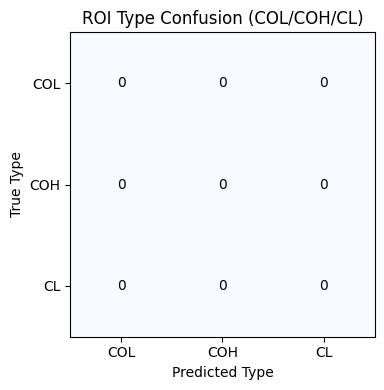

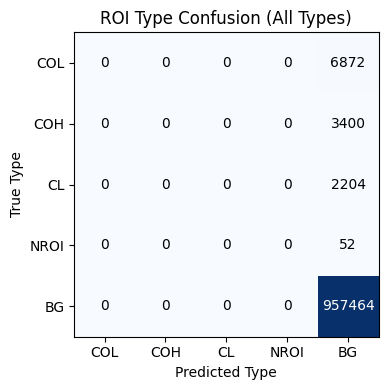

In [83]:
bg_threshold = 0.50

print(probs[:,0].mean())
print(probs[:,1].mean())
print(probs[:,2].mean())
print(probs[:,4].mean())

#y_type_pred = np.where(probs[:, 4] > bg_threshold, 4, probs[:, :4].argmax(axis=1))
y_type_pred = probs.argmax(axis=1)

pred_types_strings = [label_to_type[int(p)] for p in y_type_pred]
true_types_strings = [label_to_type[int(t)] for t in y_type_te]

#3x3 matrix (COL/COH/CL only)
labels3 = ["COL", "COH", "CL"]
mask_3class = np.array([t in labels3 for t in true_types_strings])
cm_types_3 = confusion_matrix(
    np.array(true_types_strings)[mask_3class],
    np.array(pred_types_strings)[mask_3class],
    labels=labels3
)

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_3, cmap="Blues")
plt.title("ROI Type Confusion (COL/COH/CL)")
plt.xticks(range(len(labels3)), labels3)
plt.yticks(range(len(labels3)), labels3)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(labels3)):
    for j in range(len(labels3)):
        val = cm_types_3[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_3.max()/2 else "black")
plt.tight_layout()
plt.show()

# 5x5 matrix (all ROI types including NROI)
labels4 = ["COL", "COH", "CL", "NROI", "BG"]
cm_types_4 = confusion_matrix(true_types_strings, pred_types_strings, labels=labels4)

plt.figure(figsize=(5, 4))
plt.imshow(cm_types_4, cmap="Blues")
plt.title("ROI Type Confusion (All Types)")
plt.xticks(range(len(labels4)), labels4)
plt.yticks(range(len(labels4)), labels4)
plt.xlabel("Predicted Type")
plt.ylabel("True Type")
for i in range(len(labels4)):
    for j in range(len(labels4)):
        val = cm_types_4[i, j]
        plt.text(j, i, val, ha="center", va="center",
                color="white" if val > cm_types_4.max()/2 else "black")
plt.tight_layout()
plt.show()

In [84]:
# Per-type metrics
from sklearn.metrics import classification_report
print("\n=== ROI Type Classification Report ===")
print(classification_report(true_types_strings, pred_types_strings, labels=labels4))

# Calculate per-type recall
support = np.array([(np.array(true_types_strings) == t).sum() for t in labels4], dtype=float)
diag = np.diag(cm_types_4).astype(float)
recall_by_type = {t: (d / s if s > 0 else 0.0) for t, d, s in zip(labels4, diag, support)}
print("\nPer-type recall:", recall_by_type)

# F1 score
from sklearn.metrics import f1_score
print(f"Weighted F1 score: {f1_score(true_types_strings, pred_types_strings, average='weighted', labels=labels4):.3f}")




=== ROI Type Classification Report ===


c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nelsobt\BCSCI_Research\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

              precision    recall  f1-score   support

         COL       0.00      0.00      0.00      6872
         COH       0.00      0.00      0.00      3400
          CL       0.00      0.00      0.00      2204
        NROI       0.00      0.00      0.00        52
          BG       0.99      1.00      0.99    957464

    accuracy                           0.99    969992
   macro avg       0.20      0.20      0.20    969992
weighted avg       0.97      0.99      0.98    969992


Per-type recall: {'COL': np.float64(0.0), 'COH': np.float64(0.0), 'CL': np.float64(0.0), 'NROI': np.float64(0.0), 'BG': np.float64(1.0)}
Weighted F1 score: 0.981


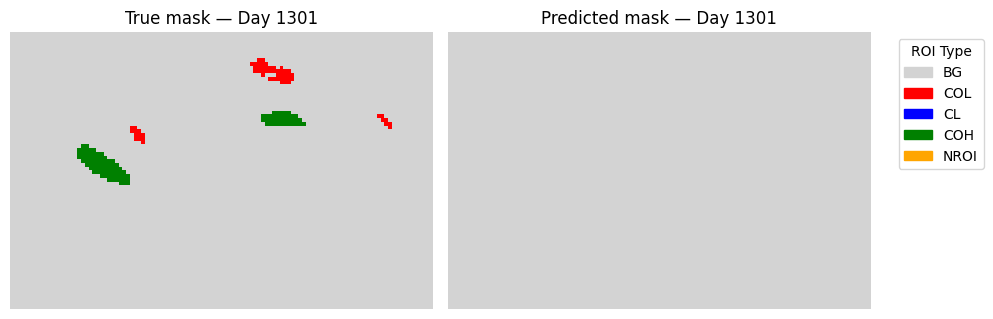

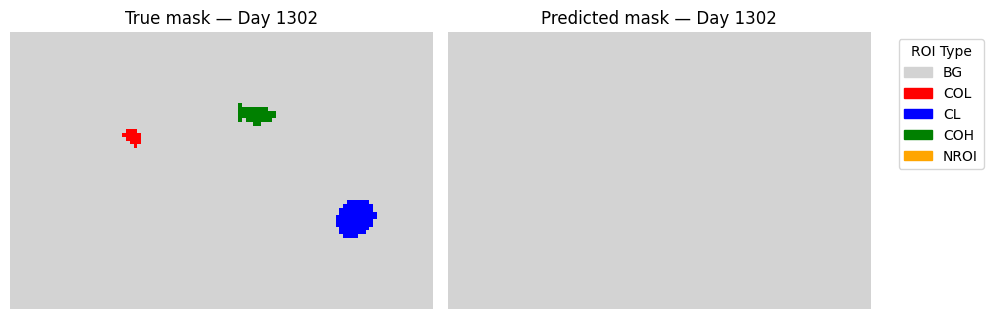

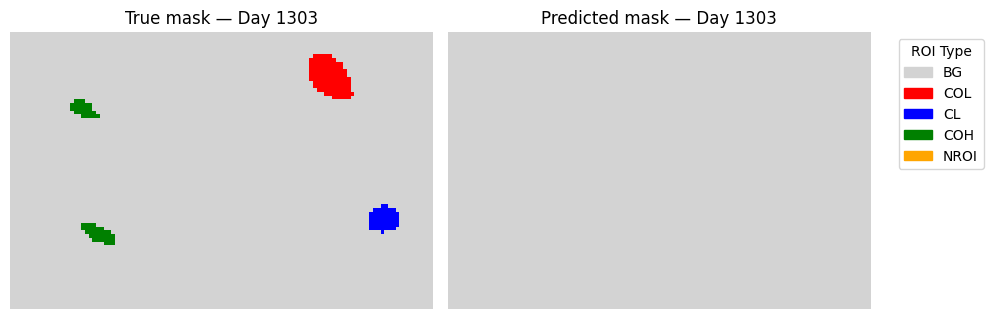

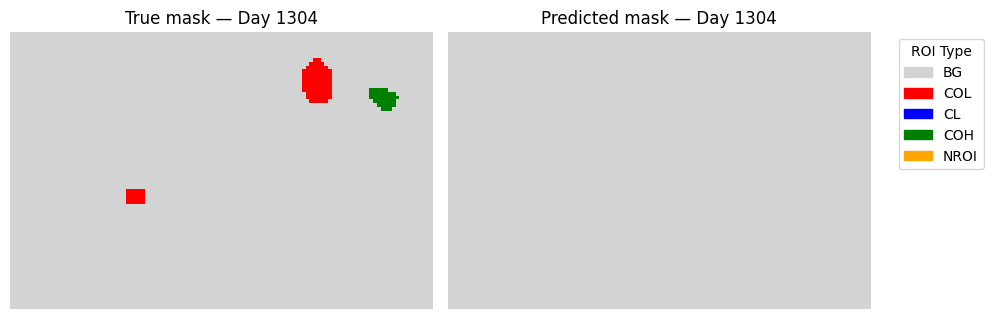

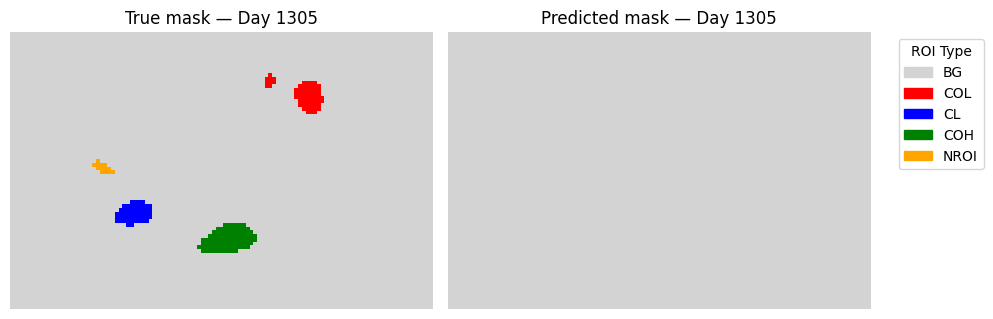

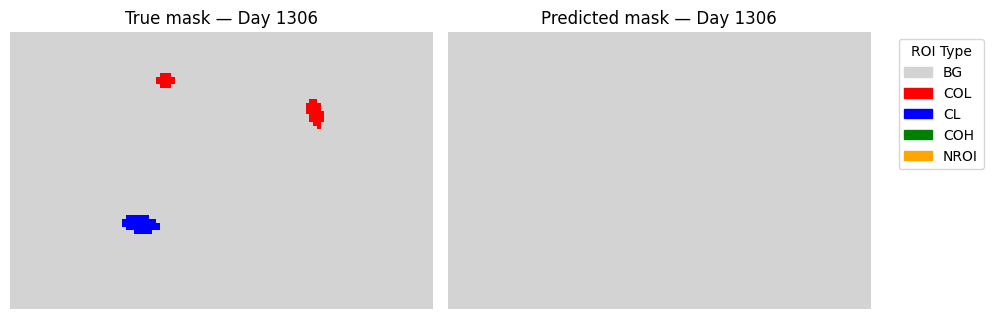

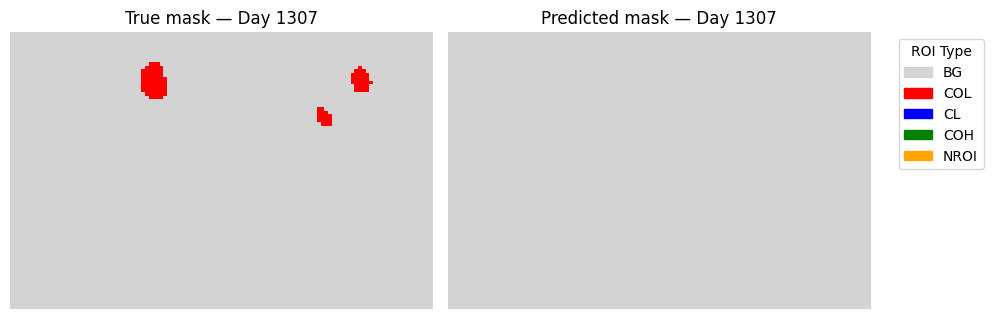

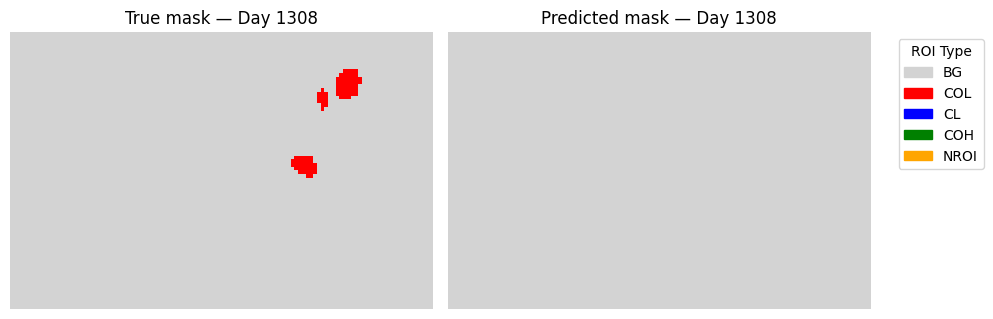

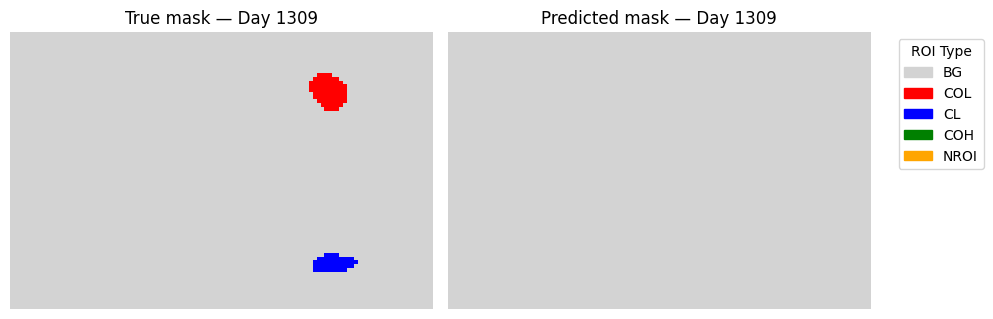

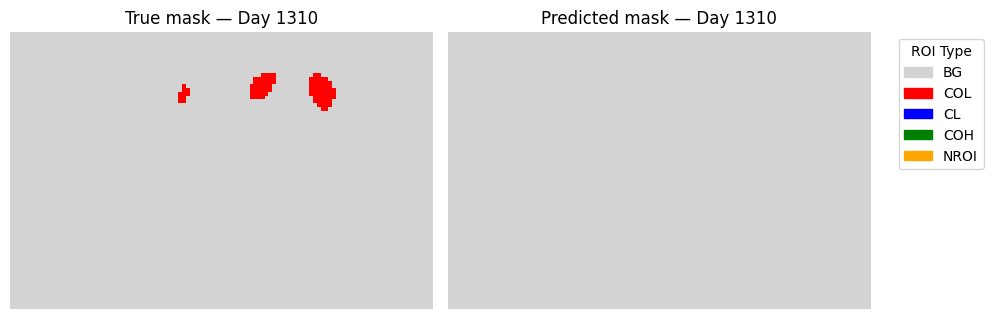

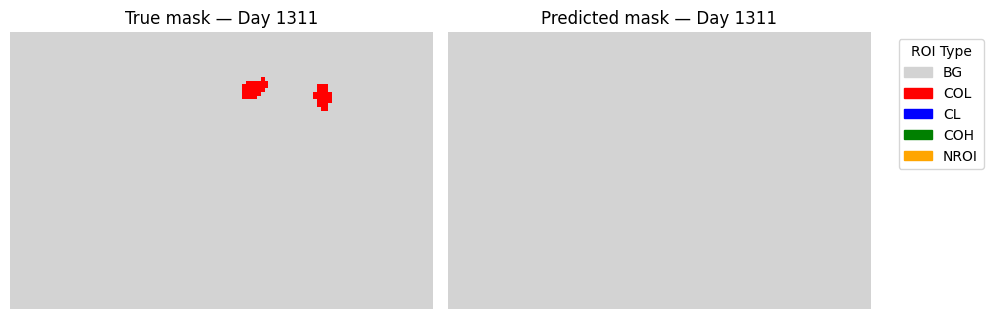

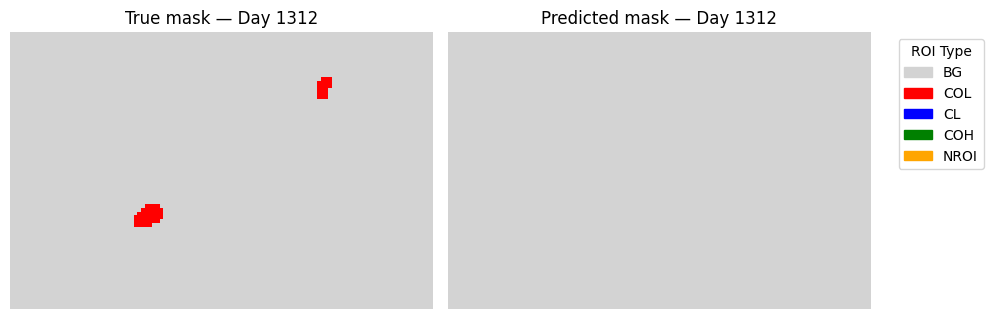

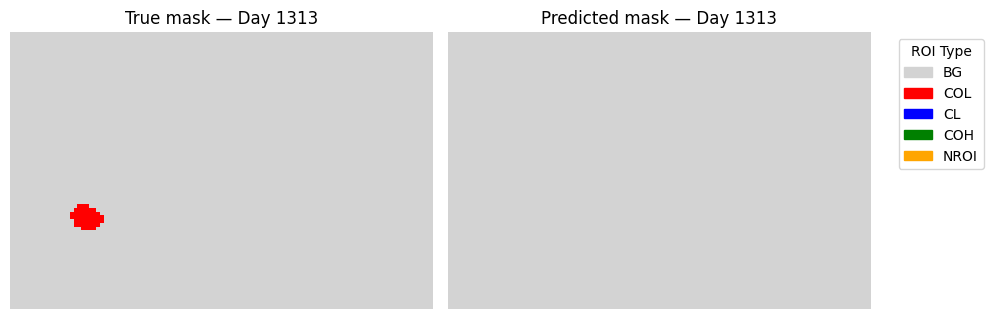

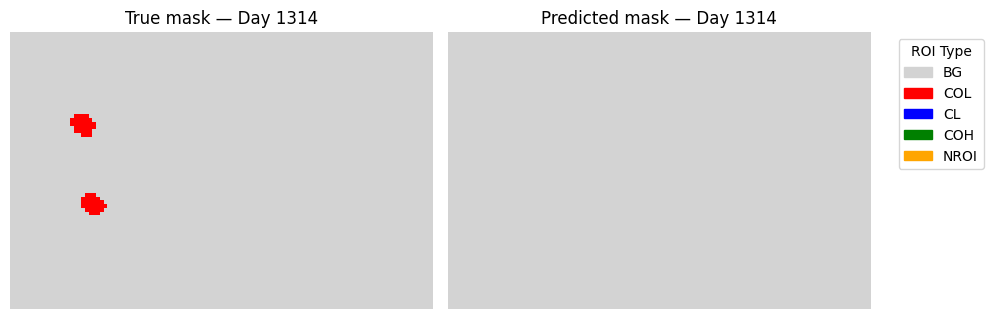

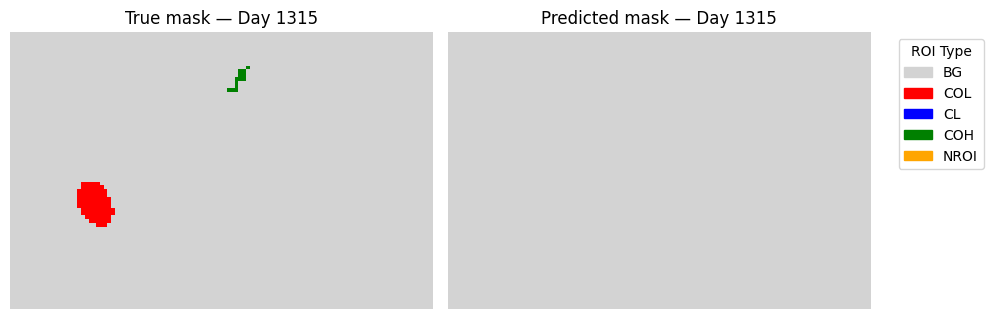

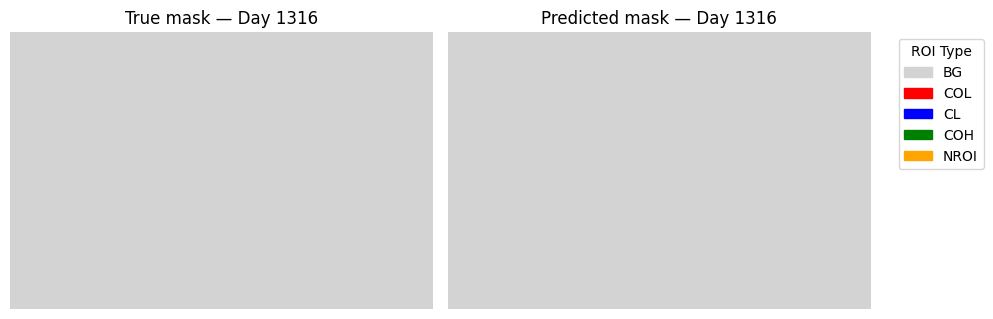

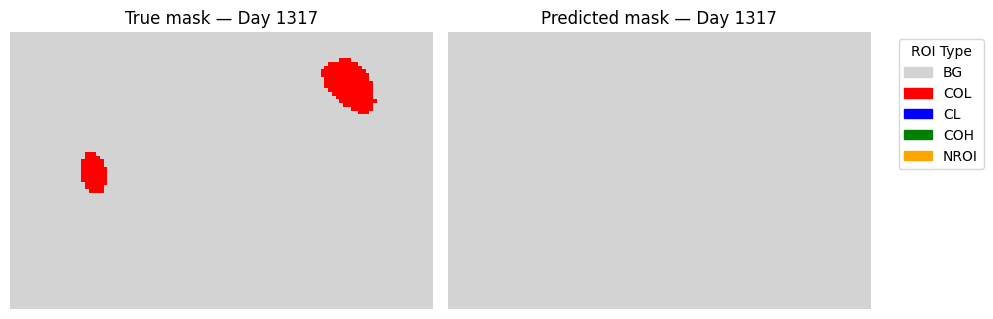

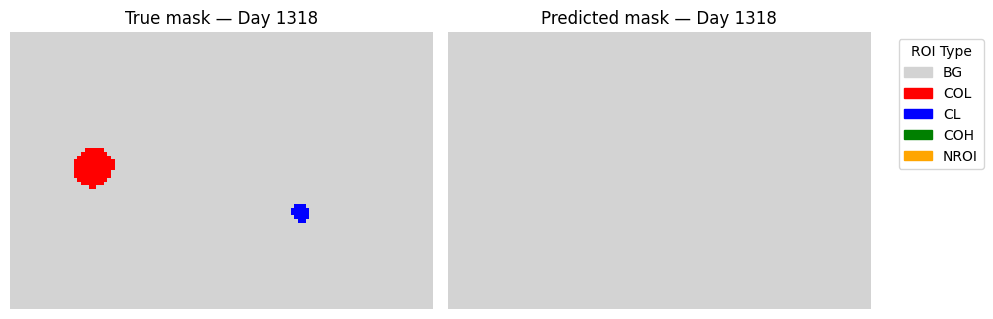

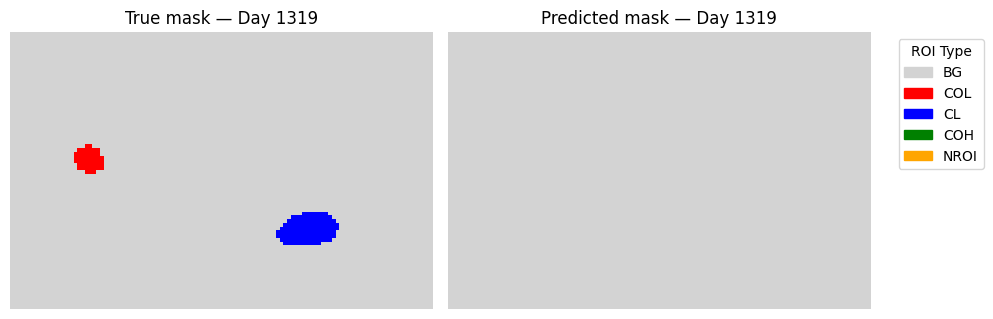

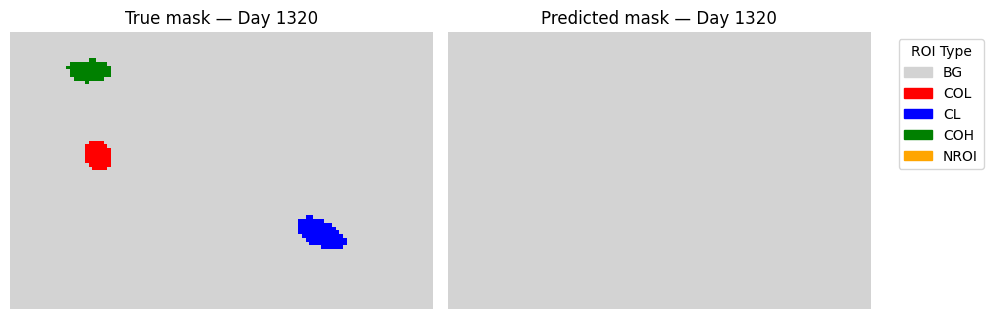

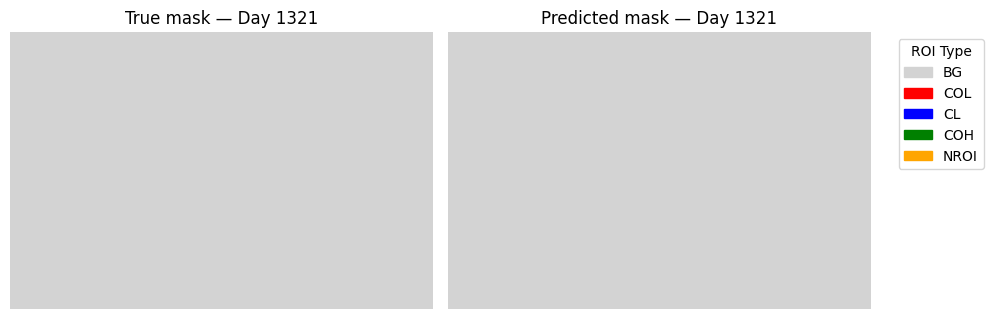

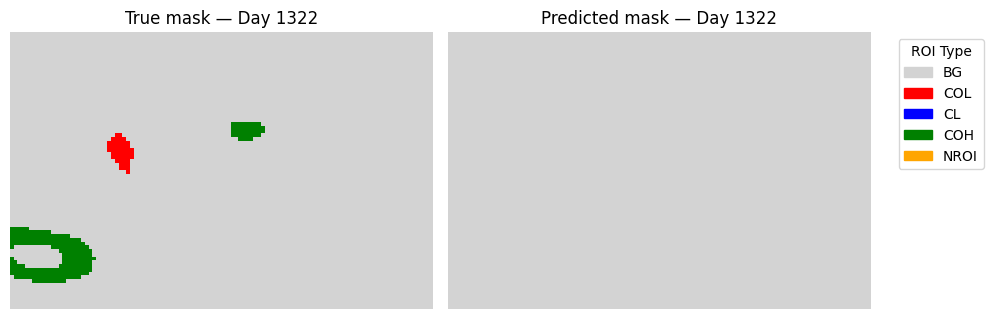

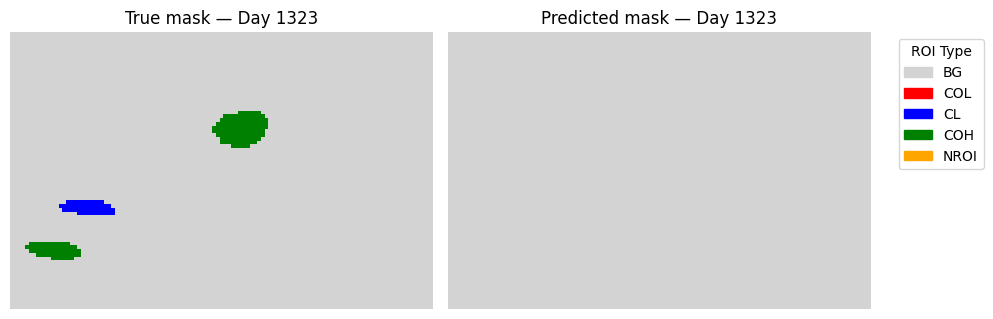

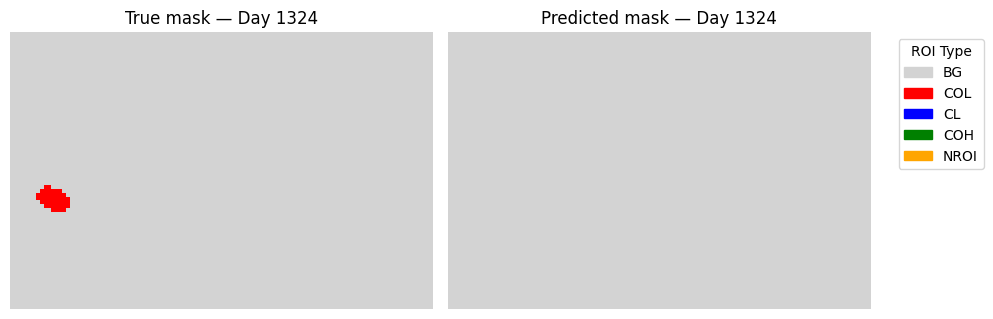

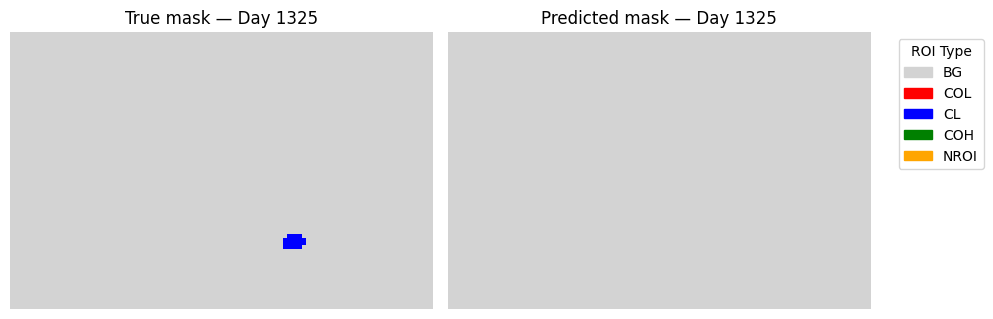

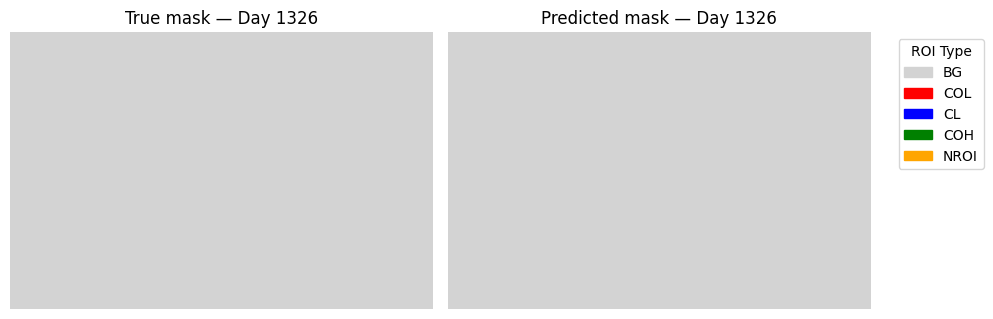

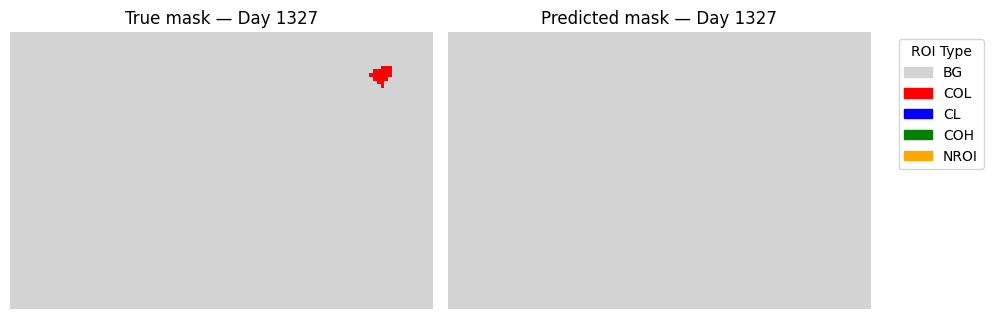

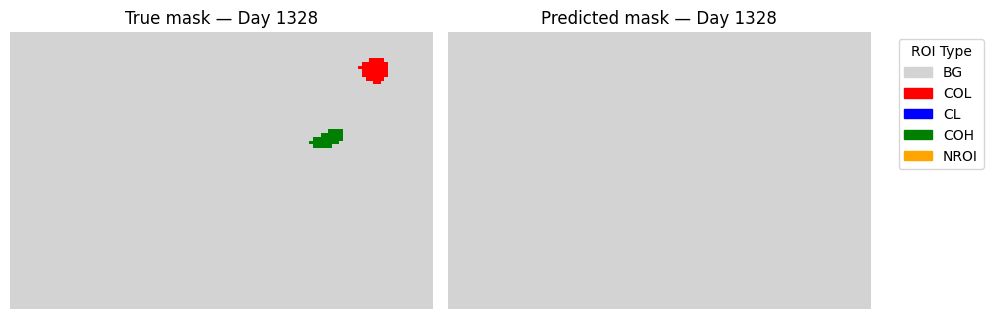

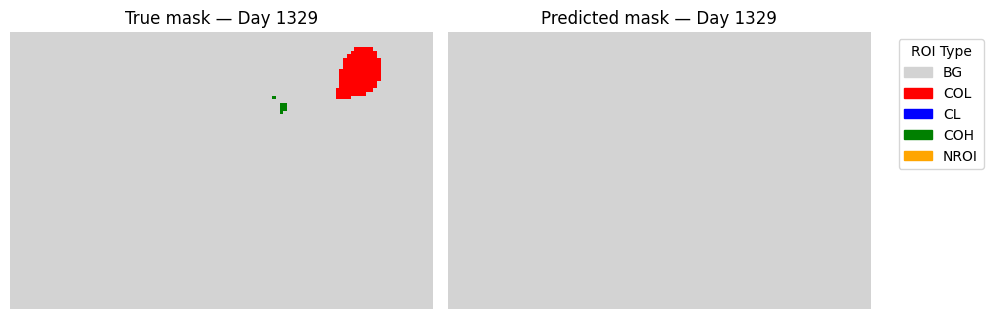

In [85]:
# === TRUE vs. PREDICTED ROI MASKS (color‐coded by type) ===
cmap_types = mcolors.ListedColormap(["lightgrey"] + ([TYPE_COLORS[t] for t in ROI_TYPES]))
type_code  = {t:i for i,t in enumerate(ROI_TYPES)}
for day in TEST_DAYS:
    P,_        = load_grids(day-1)
    H,W        = P.shape
    true_mask  = create_roi_mask(roi_df,day,(H,W))
    sel        = (days_te==day)
    coords_day = coords_te[sel]
    types_day  = types_te[sel]
    preds_day  = y_type_pred[sel]

    pred_mask = np.zeros((H,W),dtype=int)
    for (x,y), pr in zip(coords_day, preds_day):
        if pr != 4:
            pred_mask[H-1-y, x] = pr+1

    fig,(axT,axP) = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True)
    axT.imshow(true_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axT.set_title(f"True mask — Day {day}");  axT.axis("off")
    axP.imshow(pred_mask, cmap=cmap_types, origin="upper", vmin=0, vmax=len(ROI_TYPES))
    axP.set_title(f"Predicted mask — Day {day}"); axP.axis("off")

    patches = [mpatches.Patch(color=cmap_types(i), label=l)
            for i,l in enumerate(["BG"]+ROI_TYPES)]
    axP.legend(handles=patches, bbox_to_anchor=(1.05,1), loc="upper left", title="ROI Type")
    axT.invert_yaxis()
    axP.invert_yaxis()
    plt.tight_layout()
    plt.show()